# 6. Sensitivity and Robustness

Notebook 6 keeps the analysis practical rather than theoretical. The preceding notebooks show that the priority reserve/floor policy is attractive under replay, support-aware OPE, conservative lower-tail ranking, and observed segment heterogeneity. This notebook asks what could still break that offline recommendation.

The two main risks are:

1. **Marketplace-response risk:** bidders, budgets, or pacing systems may react when floors change.
2. **Support fragility:** model-assisted lower-tail evidence can weaken if effective support is worse than the simulated logger suggests.

The output is a robustness bridge between OPE and validation. It does not prove launch readiness. It quantifies why the policy deserves validation and why direct launch remains too strong a claim.


## What This Notebook Creates

Inputs from notebook 4/5:

- `metadata/marketplace_scorecard.csv`
- `metadata/reserve_policy_effects.csv`
- `metadata/advanced_policy_conservative_ranking.csv`
- OPE support and scorecard fields used to identify the priority policy and the comparison shortlist

Generated analysis artifacts:

- `metadata/equilibrium_sensitivity.csv`
- `metadata/support_collapse_curve.csv`
- `metadata/theory_guided_sensitivity_verdict.csv`
- `metadata/robustness_assumption_registry.csv`

Generated paper figures:

- `artifacts/figures/10_equilibrium_sensitivity.png`
- `artifacts/figures/10_support_collapse_curve.png`
- `artifacts/figures/10_theory_guided_verdict.png`

The third filename is retained for compatibility with the existing renderer, but the interpretation in this notebook is a robustness summary, not a formal-theory claim.



## Sensitivity Setup

The scorecard identifies the priority policy and the shortlist of comparison policies. This notebook deliberately evaluates sensitivity on multiple shortlisted policies rather than only the winner. That makes the diagnostic answer a stronger question: is the priority policy robust because all policies survive the same stress tests, or because it has meaningfully more room before adverse response and support loss erase the offline signal?

The marketplace-response curve starts from each policy's replay lift and asks how much adverse response loss would be needed before the replay advantage is erased. The support-contraction curve starts from the cross-fitted doubly robust median and lower-tail lifts, then widens the lower-tail penalty as effective support declines.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths, RawPipelineConfig
from data_access import Workspace
from figures import FigureRenderer
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger
from theory_sensitivity import TheorySensitivityBuilder


In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)
config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=True,
    clean_workspace=False,
)
paper_config = PaperConfig()

required = [
    paths.metadata_dir / "marketplace_scorecard.csv",
    paths.metadata_dir / "reserve_policy_price_landscape.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks/4_ope_estimator_diagnostics.ipynb first. "
        f"Missing: {missing}"
    )

print("Required scorecard and policy artifacts are present.")


Required scorecard and policy artifacts are present.


In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}
catalog = ReservePolicyCatalog(price_quantiles)

scorecard = repository.read_csv("marketplace_scorecard.csv")
scorecard[[
    "policy_id",
    "pct_delta_yield_per_opportunity_vs_baseline",
    "crossfit_dr_pct_lift_p10",
    "weighted_evidence_score",
    "policy_decision",
]].head(10)


,policy_id,pct_delta_yield_per_opportunity_vs_baseline,crossfit_dr_pct_lift_p10,weighted_evidence_score,policy_decision
0,hybrid_q75_if_gap_100,0.476604,0.458253,4.305,priority_shadow_log_then_switchback
1,min_positive_floor_q75,0.355075,0.282295,4.205,priority_shadow_log_then_switchback
2,hybrid_q50_if_gap_50,0.101179,0.075046,3.635,priority_shadow_log_then_switchback
3,margin_gap_100_add_20,0.097883,0.051537,3.635,priority_shadow_log_then_switchback
4,add_20_all_floors,0.097433,0.066209,3.635,priority_shadow_log_then_switchback
5,zero_and_low_floor_to_q50,0.101179,0.069217,3.585,priority_shadow_log_then_switchback
6,min_positive_floor_q50,0.072978,NaN,2.535,priority_shadow_log_then_switchback
7,margin_gap_50_add_10,0.040727,NaN,2.535,priority_shadow_log_then_switchback
8,add_10_all_floors,0.040310,NaN,2.535,priority_shadow_log_then_switchback
9,uniform_raise_30pct,0.069190,NaN,2.385,priority_shadow_log_then_switchback


## Build Robustness Artifacts

Set `RUN_SENSITIVITY = True` for a fresh run. This is lightweight compared with OPE because it operates on replay and scorecard summaries rather than refitting models. The generated curves use the six-policy comparison set used in the paper: the priority policy, two main quantile-floor alternatives, and three simpler reserve-increase rules.



In [5]:
RUN_SENSITIVITY = True

# Reload only this local module so edits to src/theory_sensitivity.py are picked up
# even when the notebook kernel has been running for a while.
import importlib
import theory_sensitivity

importlib.reload(theory_sensitivity)
builder = theory_sensitivity.TheorySensitivityBuilder(workspace, config, catalog, progress=progress)

if RUN_SENSITIVITY:
    builder.build_theory_and_sensitivity(scorecard)

response = repository.read_csv("equilibrium_sensitivity.csv")
support = repository.read_csv("support_collapse_curve.csv")
verdict = repository.read_csv("theory_guided_sensitivity_verdict.csv")

print(f"Response-sensitivity rows: {len(response):,}")
print(f"Support-sensitivity rows: {len(support):,}")
verdict


[     0.3s] Starting: sensitivity, robustness, and launch-readiness artifacts
[     0.3s] Finished: sensitivity, robustness, and launch-readiness artifacts
Response-sensitivity rows: 186
Support-sensitivity rows: 36


,policy_id,top_policy_replay_lift,top_policy_p10_dr_lift,top_policy_break_even_response_loss,tests_passed,tests_review,replay_lift,conservative_dr_p10_lift,break_even_market_response_loss_share,support_verdict,launch_verdict
0,hybrid_q75_if_gap_100,0.476604,0.458253,0.32277,5,0,0.476604,0.458253,0.32277,shadow logging required,validate online before launch


## Marketplace-Response Sensitivity

Replay holds logged bids and participation fixed. That is useful for screening, but it is not a live-launch treatment effect. If floors change in production, bidders may shade bids, budgets may pace differently, or demand may move elsewhere. The response-sensitivity curve therefore applies the same adverse response-loss share to each shortlisted policy's replay yield and asks how quickly the advantage over the logged-floor baseline disappears.



Wrote marketplace-response sensitivity figure to artifacts/figures/10_equilibrium_sensitivity.png


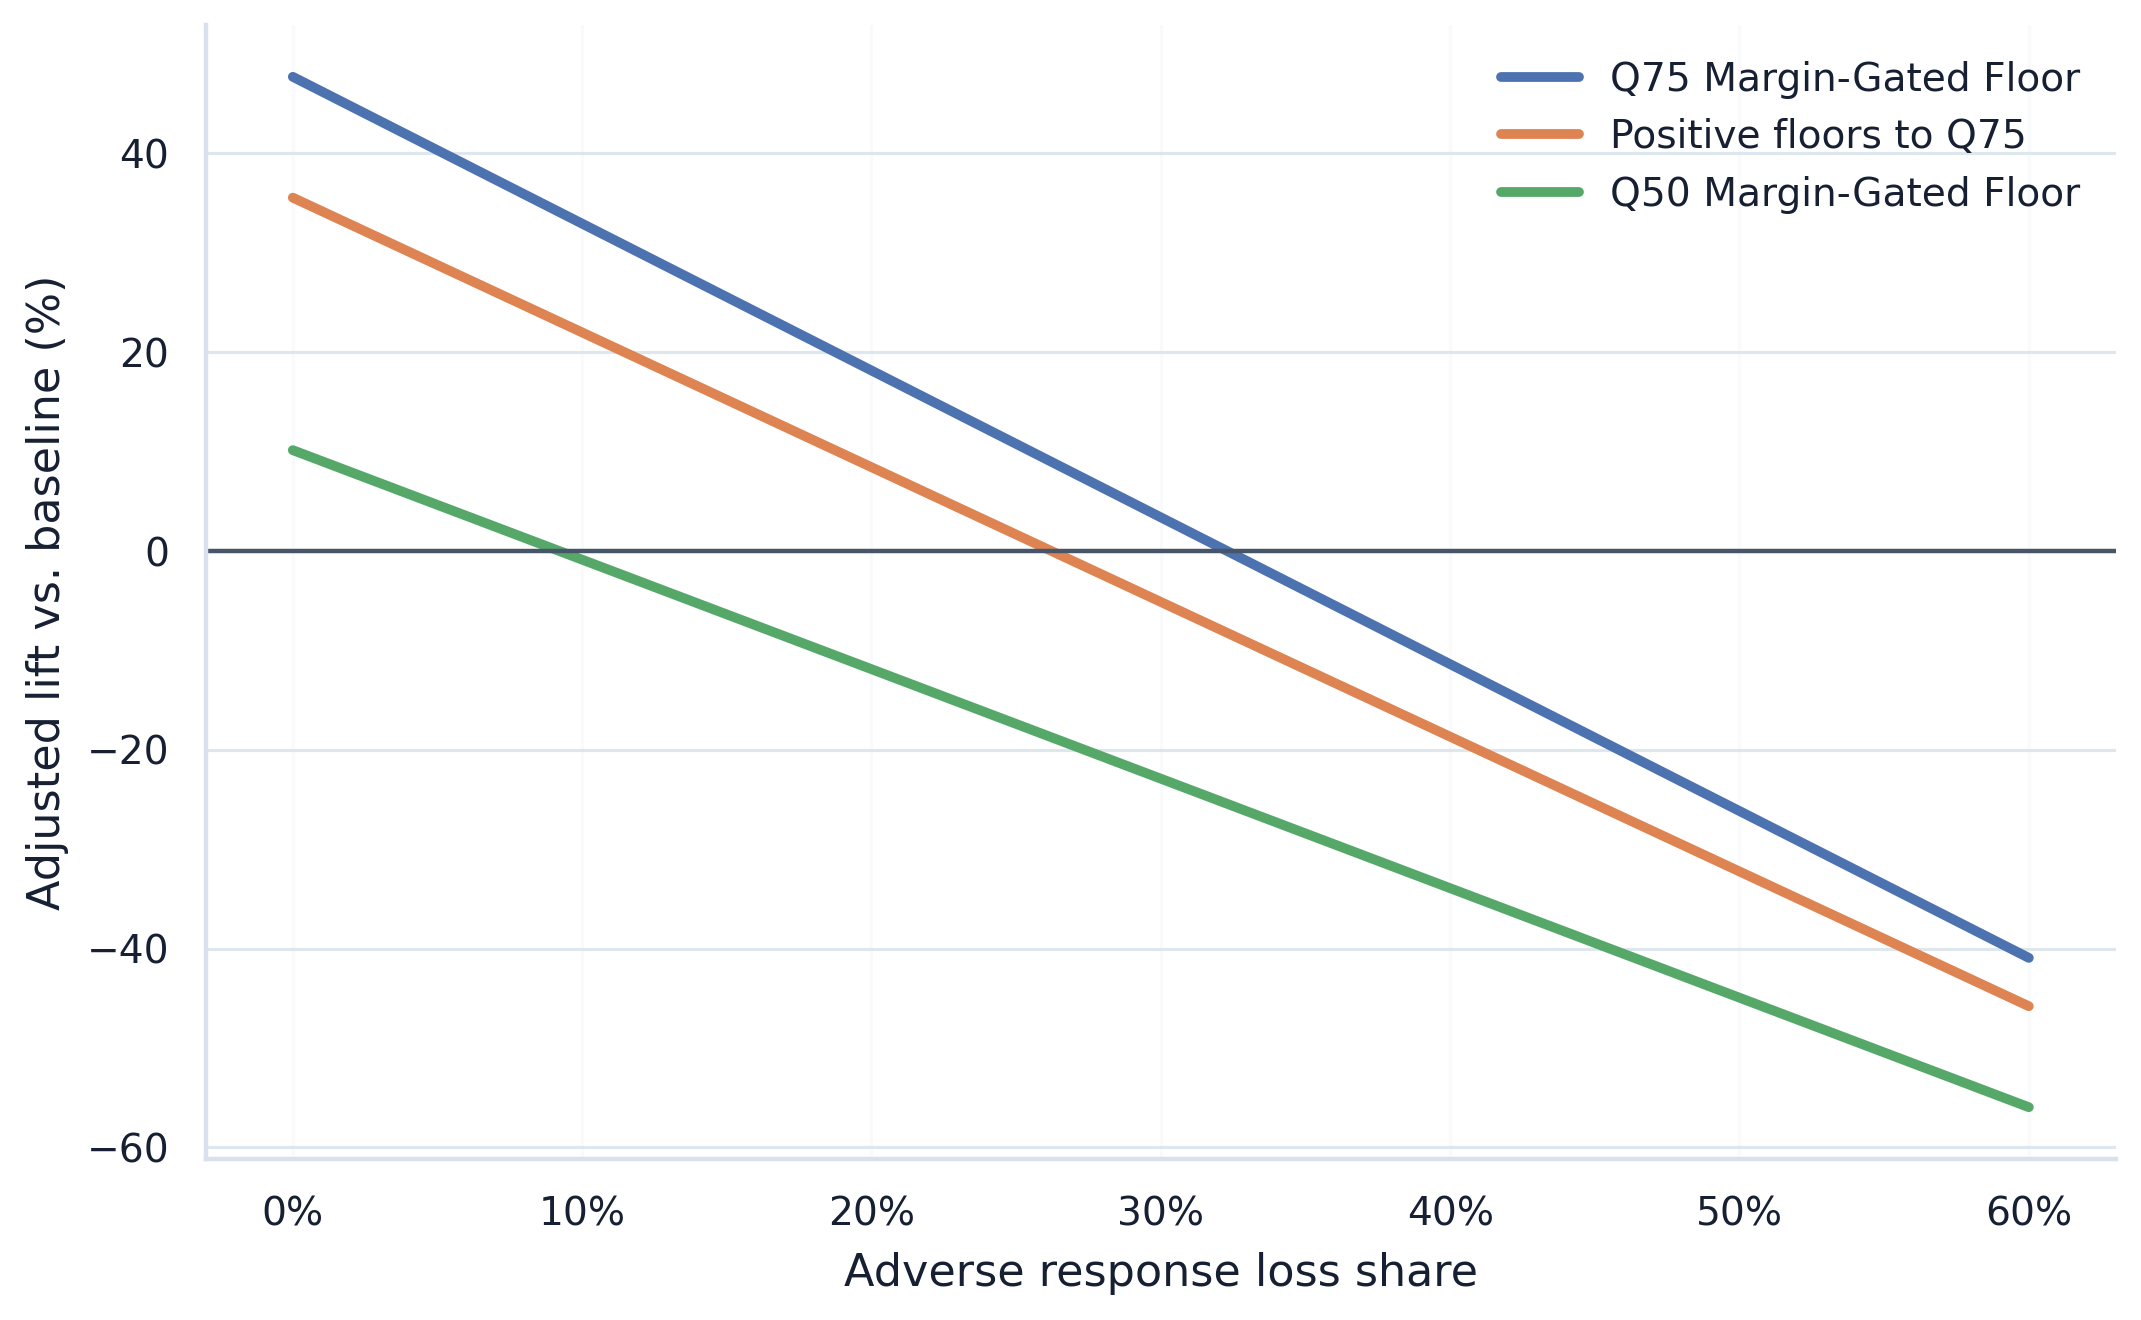

In [6]:
renderer = FigureRenderer(repository, paths.figure_dir, paper_config, progress=progress)
response_path = renderer.plot_equilibrium_sensitivity()
print(f"Wrote marketplace-response sensitivity figure to {response_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(response_path)))


The key interpretation is not that the exact response curve is a forecast. It is a stress test. A policy with a large replay lift can tolerate more adverse response before losing its advantage. A policy with a small replay lift would be fragile to even modest response loss. This is why response sensitivity supports validation priority but not direct launch.


## Effective-Support Sensitivity

The OPE diagnostics rely on support. If a target policy is poorly covered by the logged or simulated assignment mechanism, then lower-tail estimates become less reliable. The support-contraction curve starts at the observed cross-fitted DR p10 lift and then expands the median-to-p10 uncertainty gap by `1 / sqrt(support_scale)`. This keeps the diagnostic tied to the empirical lower-tail estimates while making the stress test more conservative as effective support declines.



Wrote support-collapse sensitivity figure to artifacts/figures/10_support_collapse_curve.png


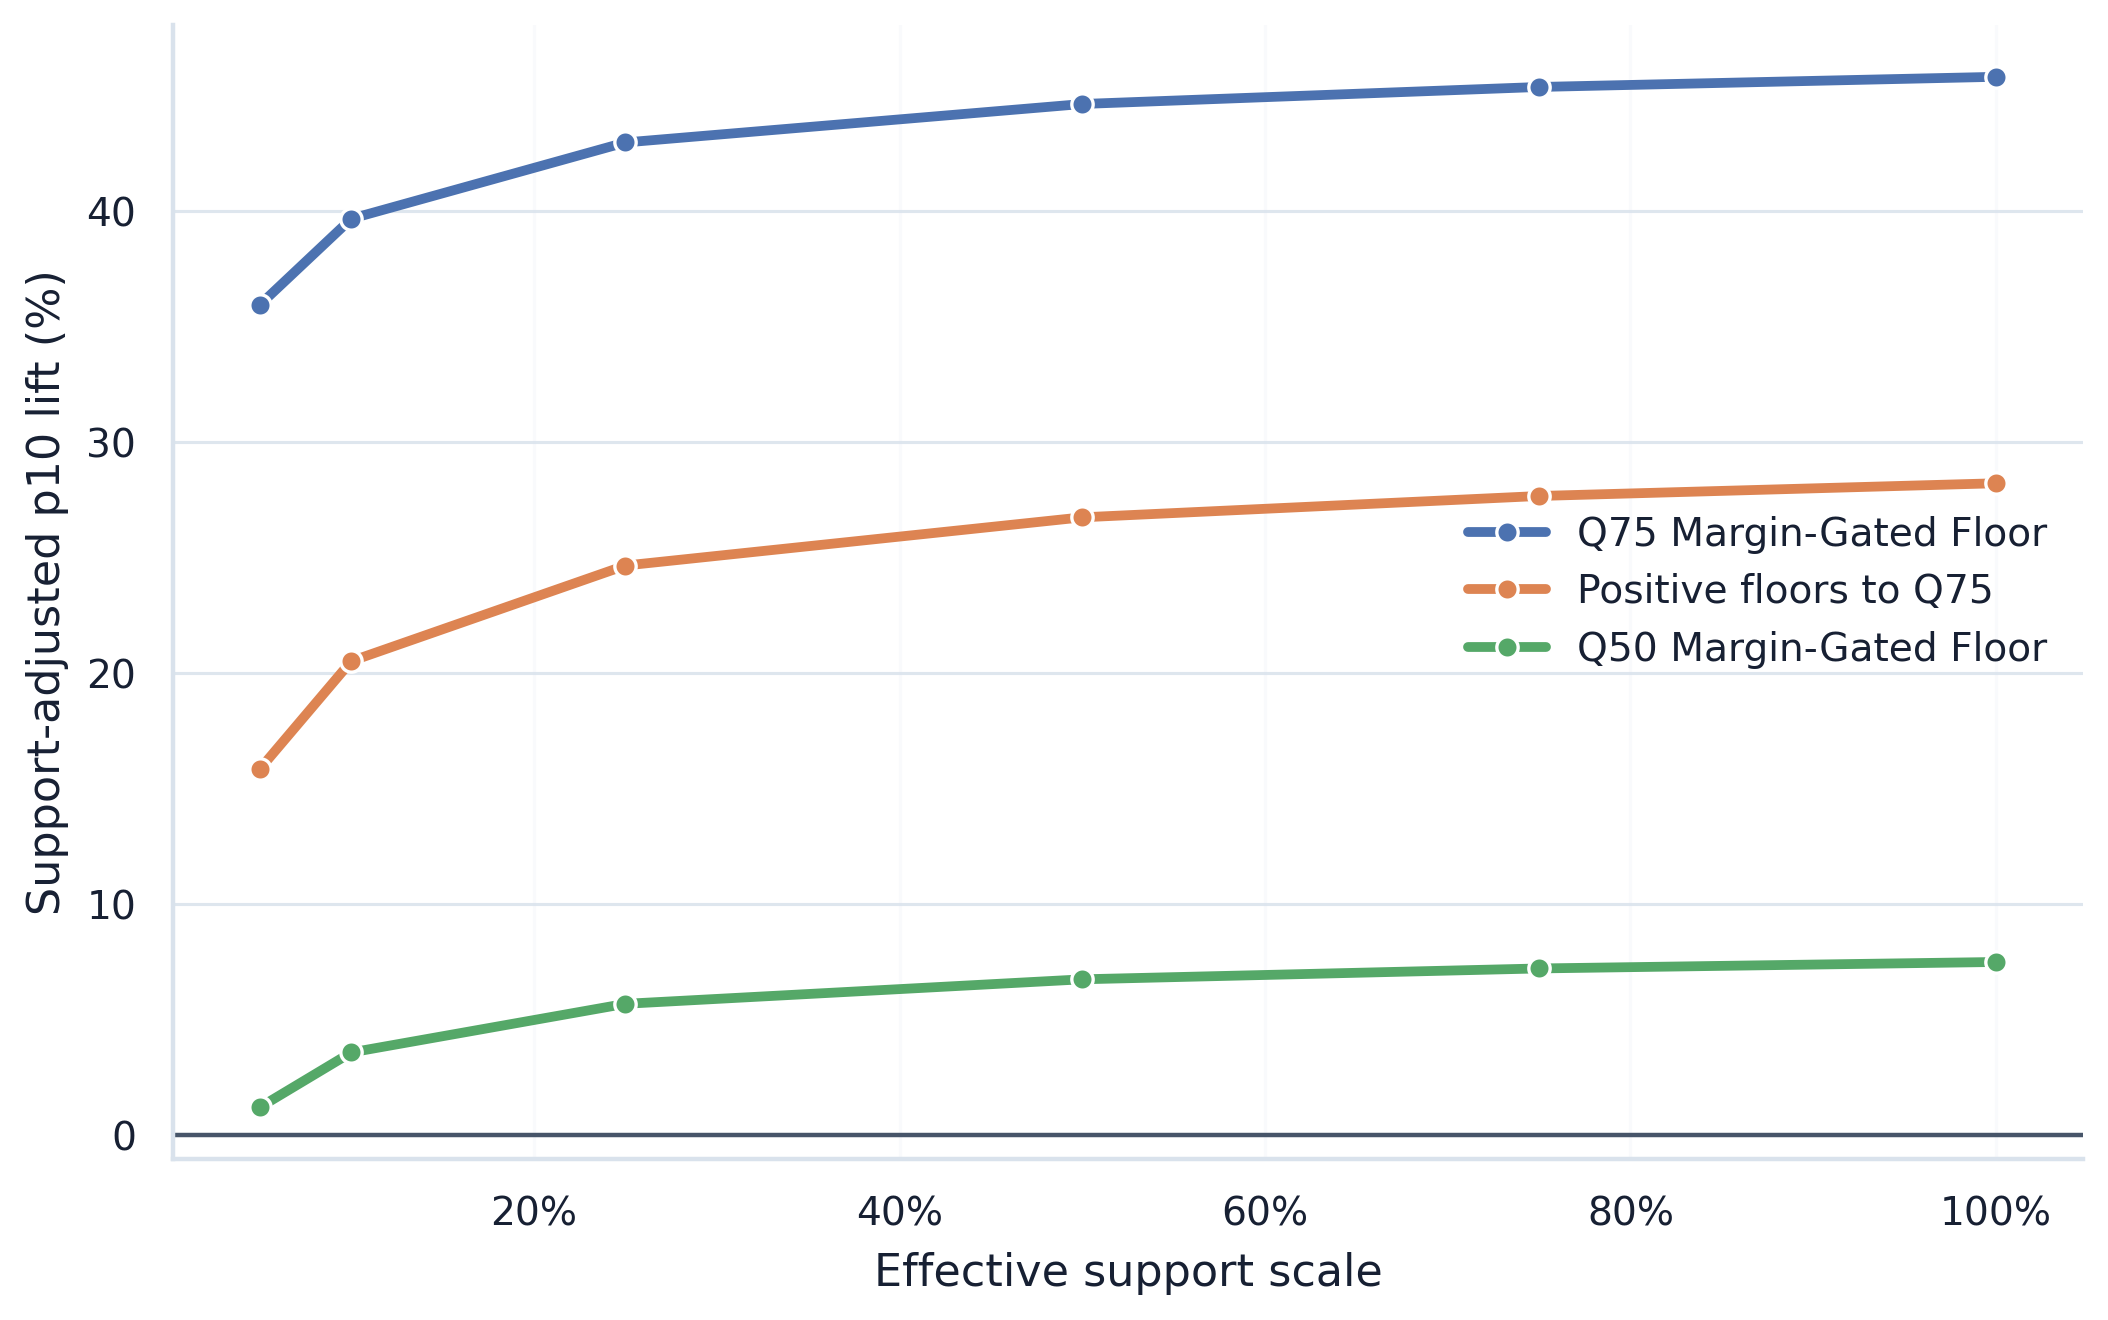

In [7]:
support_path = renderer.plot_support_collapse()
print(f"Wrote support-collapse sensitivity figure to {support_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(support_path)))


This curve connects directly to the weight diagnostics from notebook 4. Strong support allows OPE evidence to contribute meaningfully to validation priority. Weak support does not kill the replay result, but it reduces the credibility of model-assisted estimates and increases the need for shadow logging or a controlled online design.


## Robustness Summary

The robustness summary compresses the sensitivity results into a small decision-facing diagnostic. It records the priority policy's replay lift, lower-tail DR lift, break-even response-loss share, and recommended launch posture.


Wrote robustness summary figure to artifacts/figures/10_theory_guided_verdict.png


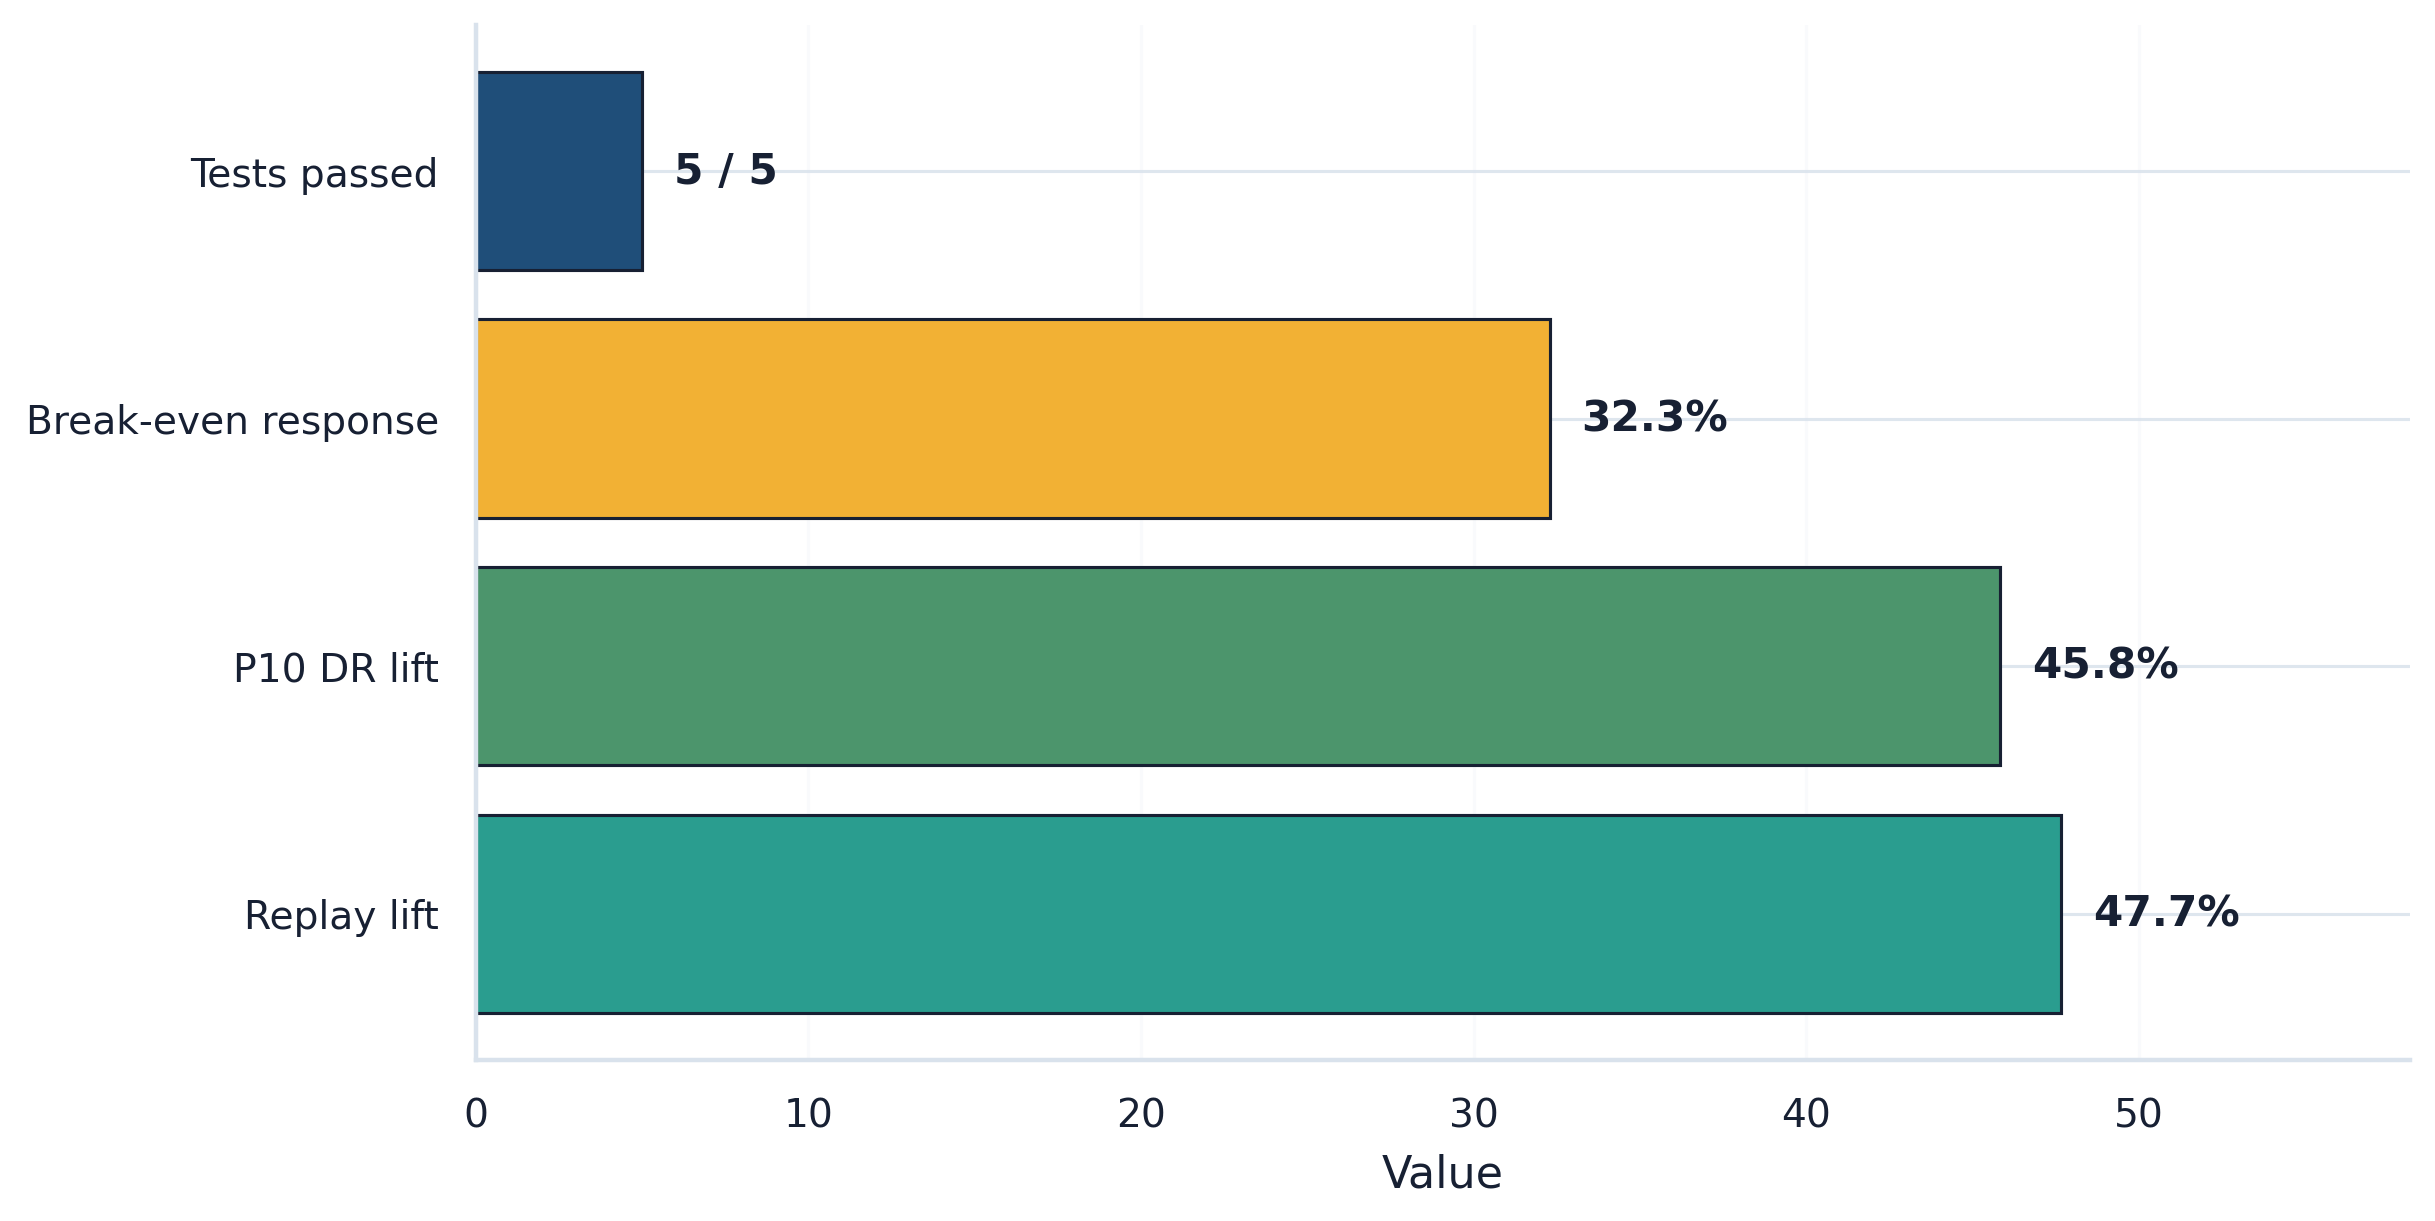

In [8]:
summary_path = renderer.plot_theory_verdict()
print(f"Wrote robustness summary figure to {summary_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(summary_path)))


In [9]:
verdict[[
    "policy_id",
    "replay_lift",
    "conservative_dr_p10_lift",
    "break_even_market_response_loss_share",
    "support_verdict",
    "launch_verdict",
]]


,policy_id,replay_lift,conservative_dr_p10_lift,break_even_market_response_loss_share,support_verdict,launch_verdict
0,hybrid_q75_if_gap_100,0.476604,0.458253,0.32277,shadow logging required,validate online before launch


## Interpretation for the Paper

This notebook changes the tone of the evidence from "the policy looks good offline" to "the policy looks good enough to validate carefully." Marketplace-response sensitivity addresses the main limitation of replay: bids and participation may change when floors change. Effective-support sensitivity addresses the main limitation of OPE: lower-tail evidence depends on overlap and weight behavior.

The important design choice is that these stress tests are applied to a policy set, not only to the final recommendation. The priority policy should remain attractive relative to credible alternatives under the same adverse-response and support-contraction assumptions. The resulting recommendation is intentionally conservative: the priority policy has enough offline upside and robustness to justify validation capacity, but unresolved response and support risks prevent a direct launch claim.

